
# sentiment analysis  
  Sentiment analysis is a technique that uses natural language processing and machine learning to analyze the emotions and opinions expressed in text. It can help businesses and organizations understand how their customers, employees, and stakeholders feel about their products, services, or policies.

  Sentiment analysis can be applied to various types of text, such as reviews, social media posts, surveys, emails, news articles, and more. It can also be performed at different levels of granularity, such as document-level, sentence-level, or aspect-level.

## Some of the benefits of sentiment analysis are:

* It can help improve customer satisfaction and loyalty by identifying and addressing customer pain points, expectations, and preferences.  
* It can help monitor brand reputation and sentiment trends by tracking and analyzing online mentions and feedback.  
* It can help optimize marketing and advertising strategies by measuring the effectiveness and impact of campaigns and content.  
* It can help enhance product and service quality by discovering customer needs, wants, and suggestions.  
* It can help support decision making and policy making by providing insights into public opinion and sentiment.  
  
Sentiment analysis is not a trivial task, as it involves dealing with complex and nuanced aspects of human language, such as sarcasm, irony, humor, slang, and context. Therefore, sentiment analysis systems need to be trained on large and diverse datasets, and use advanced natural language processing and machine learning techniques, such as deep learning, word embeddings, and transformers.

Sentiment analysis is an active and evolving research field, with many challenges and opportunities for innovation and improvement. Some of the current and future trends in sentiment analysis are:

* Multilingual and cross-lingual sentiment analysis, which aims to analyze text in different languages and across languages.  
* Multimodal sentiment analysis, which integrates text with other modalities, such as audio, video, and images.  
* Fine-grained sentiment analysis, which goes beyond the basic polarity of positive, negative, and neutral, and captures more specific and subtle emotions and attitudes, such as anger, joy, surprise, etc.  
* Aspect-based sentiment analysis, which identifies and analyzes the sentiment towards specific features or aspects of a product, service, or topic.  
* Explainable sentiment analysis, which provides explanations and justifications for the sentiment predictions and classifications.  


## Implementation  
Initially, we will start with importing and installing all the necessary libraries


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install sentencepiece
!pip install pipeline

### importing the libraries

In [ ]:
import pandas as pd
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig
from scipy.special import softmax
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from transformers import pipeline

from sklearn.metrics import classification_report


In [ ]:
MODEL =  f"cardiffnlp/twitter-xlm-roberta-base-sentiment"#
NUM = 500



### Helper function
 here we can find some helper funtions that will be needed to:
 * clean the input text.  
 * calculate the confusion matrix.
 * plot the data into visual form.

In [ ]:
def create_confusion_matrix(true_values, predicted_values):
  return confusion_matrix(true_values, predicted_values)

# Preprocess text (username and link placeholders)
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)
def plot_data(cm):
  # Create a heatmap with Matplotlib
  plt.matshow(cm, cmap=plt.cm.Blues)
  plt.title("Confusion Matrix")
  plt.colorbar()
  plt.xlabel("Predicted labels")
  plt.ylabel("True labels")
  plt.show()

### Loading data
we are going to load the data into pandas dataframe to start processing it.


In [ ]:
data_en= pd.read_json("/content/drive/MyDrive/NLP/sentiment_analysis/datasets/tweet_sentiment_multilingual_en_test.jsonl", lines=True)
data_en.head()

,text,label
0,Trying to have a conversation with my dad abou...,0
1,#latestnews 4 #newmexico #politics + #nativeam...,1
2,@user You are a stand up guy and a Gentleman V...,2
3,@user @user @user Looks like Flynn isn't too p...,0
4,perfect pussy clips #vanessa hudgens zac efron...,1


### Loading Model
we are going to load a Transformer model from Hugging Face to use it.



In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
# PT

model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

### process text
We are going to create function to do all the sentiment analysis processing
* first, we will do this test on 500 text row
* then, we start preprocessing this text 'clean it'
* after that, we are going to use tokenizer to tokenize the text data to be fitable for the transformar model
* then, we will save the highest propablitiy resutlts
* finaly, we will plot the resutls using matblotlib.

In [ ]:
# NUM =100
def start_process(data):
  results  = []

  for i, text in enumerate (data.text[:NUM]):
    text = preprocess(text)
    # print(text)
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    ranking = np.argsort(scores)
    results.append(np.argmax(ranking))
  print(results)
  # y_predicted = [np.argmax(i) for i in results]
  cm= create_confusion_matrix(data.label[:NUM],results)
  print(cm)
  plot_data(cm)
  # show report
  report = classification_report(results, data.label[:NUM])
  print(report)


[0, 0, 2, 0, 1, 2, 0, 0, 1, 0, 0, 2, 0, 1, 2, 0, 0, 1, 0, 1, 2, 0, 0, 2, 0, 1, 2, 0, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 1, 0, 0, 2, 0, 2, 1, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 2, 1, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 1, 0, 0, 0, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 0, 0, 2, 1, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 2, 1, 1, 1, 2, 1, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 1, 0, 0, 2, 0, 1, 2, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 1, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 2, 1, 0, 0, 1, 0, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 2, 0, 1, 2, 0, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 1, 0, 1, 2, 0, 0, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 2, 2, 0, 1, 0, 

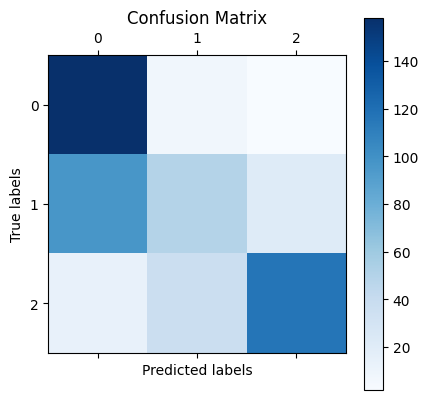

              precision    recall  f1-score   support

           0       0.95      0.59      0.73       267
           1       0.30      0.53      0.38        94
           2       0.70      0.83      0.76       139

    accuracy                           0.65       500
   macro avg       0.65      0.65      0.62       500
weighted avg       0.76      0.65      0.67       500



In [ ]:
start_process(data_en)


## Conclusion
sentiment analysis, a subtask of text classification that aims to identify the emotion or opinion behind a piece of text1.  
The article explained the problem statement of detecting hate speech in tweets, and demonstrated how to use transformers, specifically twitter-xlm-roberta-base-sentiment, to train a model on a custom dataset.  
The article concluded by highlighting the importance and applications of sentiment analysis in various domains, such as customer feedback, marketing, and social media.